# Brute force Metropolis VMC simulation

## Analytic local energy

Results for N = 1, d = 3:
Minimum energy: 1.50
Minimum alpha: 0.50
Mean accept rate: 0.733

Results for N = 10, d = 3:
Minimum energy: 15.00
Minimum alpha: 0.52
Mean accept rate: 0.723

Results for N = 100, d = 3:
Minimum energy: 149.99
Minimum alpha: 0.49
Mean accept rate: 0.722

Results for N = 500, d = 3:
Minimum energy: 747.66
Minimum alpha: 0.46
Mean accept rate: 0.724



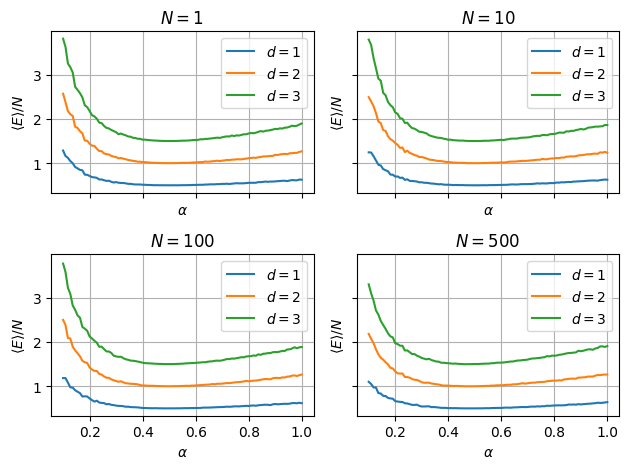

In [14]:
import matplotlib.pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_harmonic import HarmonicParamGrid
from bose_harmonic_jax import log_wavefunction_jax, local_energy_jax, HarmonicParams

base_cycles = 100_000
base_step = 1.0

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = [1, 10, 100, 500]
dims = [1, 2, 3]

fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
axs = axs.ravel()

for i, n in enumerate(number_particles):
  ax = axs[i]

  step_size = base_step / np.sqrt(n)
  #cycles = int(base_cycles * np.sqrt(n))

  for j, d in enumerate(dims):

    simulation = MetropolisJAX[HarmonicParams](n, d)
    result = simulation.grid_search_brute(
      log_wavefunction_jax, local_energy_jax, param_grid, step_size, base_cycles
    )

    energies = result.energies
    ax.plot(alpha_values, energies/n, label=f"$d = {d}$")
    ax.set_title(f"$N = {n}$")
    ax.set(xlabel=r"$\alpha$", ylabel=r"$\langle E \rangle /N$")
    ax.legend()
    ax.grid(True)

    if d == 3:
      min_energy = np.min(energies)
      min_alpha = alpha_values[np.argmin(energies)]
      print(f"Results for N = {n}, d = {d}:")
      print(f"Minimum energy: {min_energy:.2f}")
      print(f"Minimum alpha: {min_alpha:.2f}")
      print(f"Mean accept rate: {np.mean(result.accept_rates):.3f}\n")

plt.tight_layout()
plt.savefig("vmc_bose_harmonic_grid_analytic.pdf", format="pdf")
plt.show()


## Numerical local energy

Results for N = 1, d = 3:
Minimum energy: 1.500
Minimum alpha: 0.500
Mean accept rates: 0.733

Results for N = 10, d = 3:
Minimum energy: 14.997
Minimum alpha: 0.518
Mean accept rates: 0.723

Results for N = 100, d = 3:
Minimum energy: 149.994
Minimum alpha: 0.491
Mean accept rates: 0.722

Results for N = 500, d = 3:
Minimum energy: 747.662
Minimum alpha: 0.464
Mean accept rates: 0.724



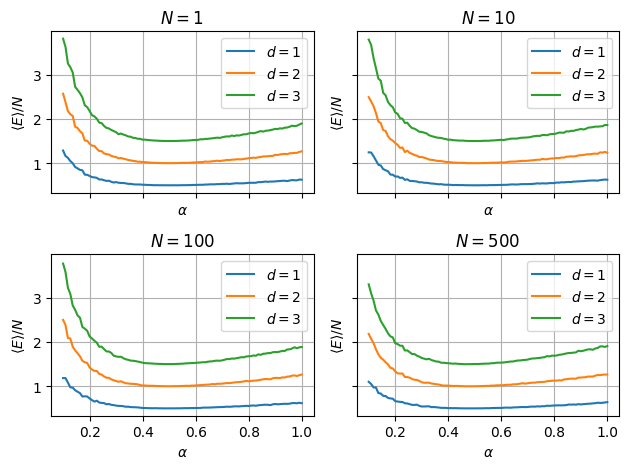

In [8]:
import matplotlib.pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_harmonic import HarmonicParamGrid
from bose_harmonic_jax import log_wavefunction_jax, local_energy_numeric_jax, HarmonicParams

base_cycles = 100_000
base_step = 1.0

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = [1, 10, 100, 500]
dims = [1, 2, 3]

fig, axs = plt.subplots(2, 2, sharex=True, sharey=True)
axs = axs.ravel()

for i, n in enumerate(number_particles):
  ax = axs[i]

  step_size = base_step / np.sqrt(n)
  #cycles = int(base_cycles * np.sqrt(n))
  
  for j, d in enumerate(dims):

    simulation = MetropolisJAX[HarmonicParams](n, d)
    result = simulation.grid_search_brute(
      log_wavefunction_jax, local_energy_numeric_jax, param_grid, step_size, base_cycles
    )
    energies = result.energies
    ax.plot(alpha_values, energies / n, label=f"$d = {d}$")
    ax.set_title(f"$N = {n}$")
    ax.set(xlabel=r"$\alpha$", ylabel=r"$\langle E \rangle /N$")
    ax.legend()
    ax.grid(True)

    if d == 3:
      min_energy = np.min(energies)
      min_alpha = alpha_values[np.argmin(energies)]
      print(f"Results for N = {n}, d = {d}:")
      print(f"Minimum energy: {min_energy:.3f}")
      print(f"Minimum alpha: {min_alpha:.3f}")
      print(f"Mean accept rates: {np.mean(result.accept_rates):.3f}\n")

plt.tight_layout()
# plt.savefig("vmc_bose_harmonic_grid_numerical.pdf", format="pdf")
plt.show()

## Comparison of analytic and numerical approach

Analytic time: 15.01 s
Numerical time: 32.19 s
Analytic is 2.14x faster


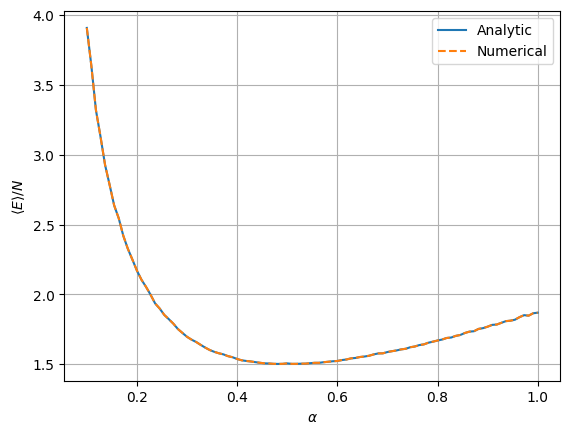

In [ ]:
import time

from matplotlib import pyplot as plt
import numpy as np

from vmc_jax import MetropolisJAX
from bose_harmonic import HarmonicParamGrid
from bose_harmonic_jax import (
  log_wavefunction_jax,
  local_energy_jax,
  local_energy_numeric_jax,
  HarmonicParams,
)

cycles = 1_000_000
base_step = 1.0 

alpha_values = np.linspace(0.1, 1.0, 100)
param_grid = HarmonicParamGrid(param_type=HarmonicParams, alpha=alpha_values)

number_particles = 100
dim = 3
step_size = base_step / np.sqrt(number_particles)

simulation = MetropolisJAX[HarmonicParams](number_particles, dim)

# Analytic
start_analytic = time.perf_counter()
result_analytic = simulation.grid_search_brute(
  log_wavefunction_jax, local_energy_jax, param_grid, step_size, cycles
)
stop_analytic = time.perf_counter()
time_analytic = stop_analytic - start_analytic

# Numerical
start_numeric = time.perf_counter()
result_numeric = simulation.grid_search_brute(
  log_wavefunction_jax, local_energy_numeric_jax, param_grid, step_size, cycles
)
stop_numeric = time.perf_counter()
time_numeric = stop_numeric - start_numeric

print(f"Analytic time: {time_analytic:.2f} s")
print(f"Numerical time: {time_numeric:.2f} s")
if time_analytic < time_numeric:
  factor = time_numeric / time_analytic
  print(f"Analytic is {factor:.2f}x faster")
else:
  factor = time_analytic / time_numeric
  print(f"Numerical is {factor:.2f}x faster")

plt.plot(alpha_values, result_analytic.energies / number_particles, label="Analytic")
plt.plot(alpha_values, result_numeric.energies / number_particles, label="Numerical", linestyle="dashed")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\langle E \rangle / N$")
plt.legend()
plt.grid(True)
plt.savefig("vmc_bose_harmonic_grid_analytic_numerical.pdf", format="pdf")
plt.show()